In [ ]:
 import math
 import numpy as np
 import matplotlib.pyplot as plt
 %matplotlib inline

In [ ]:
def f(x):
  return 3*x**2 - 4*x + 5

In [ ]:
f(9)

212

In [ ]:
x = np.arange(-5, 5, 0.25)
y = f(x)
(x,y)

(array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
        -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
        -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
         1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
         4.  ,  4.25,  4.5 ,  4.75]),
 array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
         55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
         25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
          7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
          4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
         13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
         37.    ,  42.1875,  47.75  ,  53.6875]))

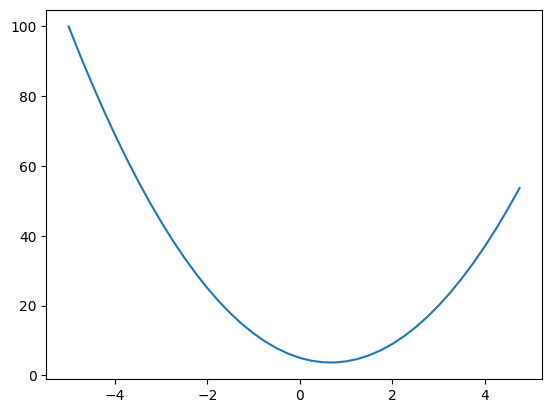

In [ ]:
plt.plot(x, y)

In [ ]:
h = 0.0001
x = 9
(f(x+h) - f(x))/h

50.000299999624076

In [ ]:
h = 0.0001
x = -9
(f(x+h) - f(x))/h

-57.99969999998211

In [ ]:
h = 0.0001
x = 2/3
(f(x+h) - f(x))/h

0.0002999999981767587

In [ ]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.001

# input
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2-d1)/h)


d1 4.0
d2 3.997
slop -3.0000000000001137


In [ ]:
h = 0.001

# input
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2-d1)/h)

d1 4.0
d2 4.002
slop 1.9999999999997797


In [ ]:
h = 0.001

# input
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slop', (d2-d1)/h)

d1 4.0
d2 4.0009999999999994
slop 0.9999999999994458


In [ ]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data = {self.data})"

In [ ]:
a = Value(2.0)
a

Value(data = 2.0)

In [ ]:
a = Value(2.0)
b = Value(3.0)

# a+b - throw error

In [ ]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data)
    return out

In [ ]:
a = Value(2.0)
b = Value(3.0)

a+b
# a.__add__(b)

Value(data = 5.0)

In [ ]:
# a*b - throw error

In [ ]:
class Value:
  def __init__(self, data):
    self.data = data

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data)
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data)
    return out

In [ ]:
a = Value(2.0)
b = Value(3.0)
c = Value(-4.0)
a*b + c
# a.__mul__(b).__add__(c)

Value(data = 2.0)

In [ ]:
# We need to keep a track of what values produce what other values

In [ ]:
class Value:
  def __init__(self, data, _children = ()):
    self.data = data
    self._prev = set(_children)

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other))
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other))
    return out

In [ ]:
a = Value(2.0)
b = Value(3.0)
c = Value(-4.0)
d = a*b + c
d
# a.__mul__(b).__add__(c)

Value(data = 2.0)

In [ ]:
d._prev

{Value(data = -4.0), Value(data = 6.0)}

In [ ]:
# Now we know the children of evry single value but we dont know which operation  created that value

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

In [ ]:
a = Value(2.0)
b = Value(3.0)
c = Value(-4.0)
d = a*b + c
d
# a.__mul__(b).__add__(c)

Value(data = 2.0)

In [ ]:
d._prev

{Value(data = -4.0), Value(data = 6.0)}

In [ ]:
d._op

'+'

In [ ]:
c._op

''

In [ ]:
# Now we want to visualize this expression

In [ ]:
# Copied code and changed it slighly (added ._op)

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f }" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
# adding label to the graph

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

In [ ]:
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(-4.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data = -4.0)

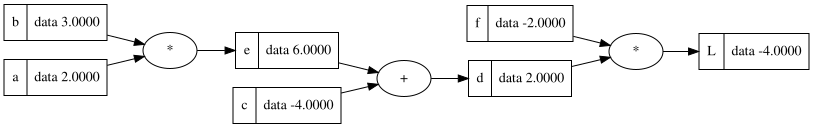

In [ ]:
draw_dot(L)

In [ ]:
# Now lets create a d erivative

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

In [ ]:
# changing graphviz a bit
def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
a = Value(2.0, label='a')
b = Value(3.0, label='b')
c = Value(-4.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data = -4.0)

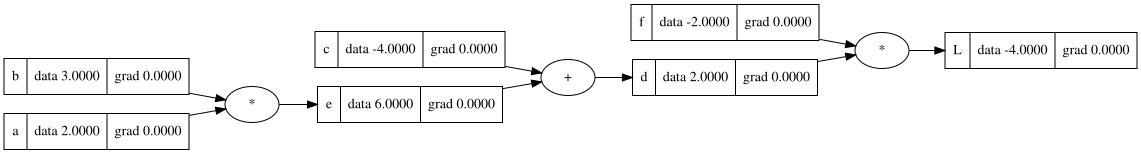

In [ ]:
draw_dot(L)

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.7, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2+w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

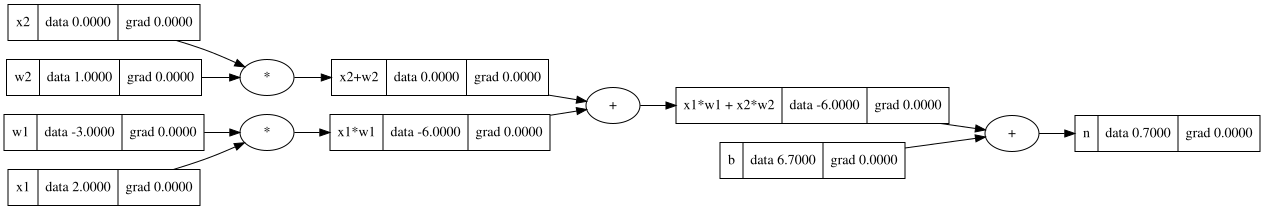

In [ ]:
draw_dot(n)

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")
    return out

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

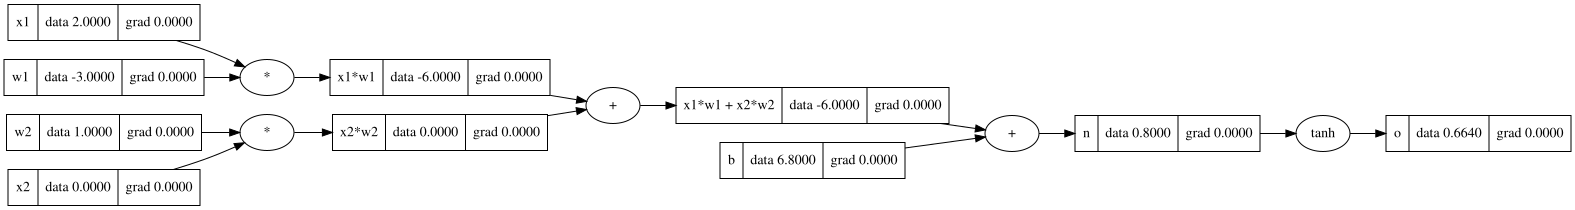

In [ ]:
draw_dot(o)

In [ ]:
o.grad = 1

In [ ]:
# n.grad = do/dn = dtanh(n)/n = 1 - tanh(n)**2
n.grad = 1 - (o.data)**2
n.grad

0.5590551677322441

In [ ]:
# n = x1w1_x2w2 + b
# add operator is ther so grad will pass on
# thus
b.grad = n.grad
x1w1_x2w2.grad = n.grad

In [ ]:
# again add operator for
# x1w1_x2w2 = x1w1 + x2w2
x1w1.grad = x1w1_x2w2.grad
x2w2.grad = x1w1_x2w2.grad

In [ ]:
# mul operator thus
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

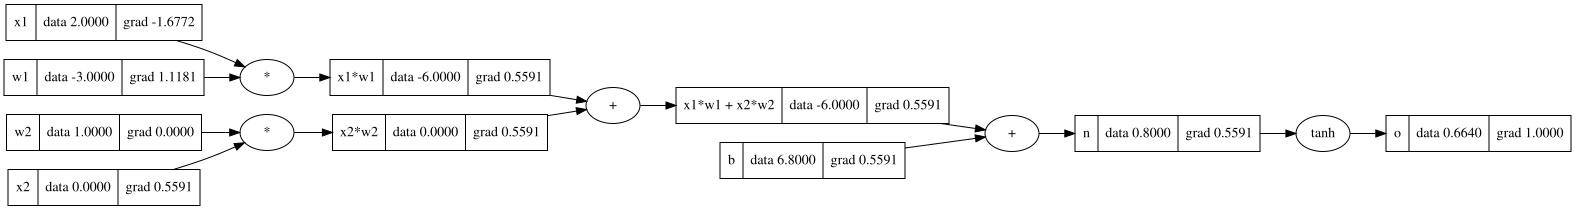

In [ ]:
draw_dot(o)

In [ ]:
# calculating the grad

In [ ]:
from ast import Lambda
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad = (1 - t**2) * out.grad

    out._backward = _backward
    return out

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

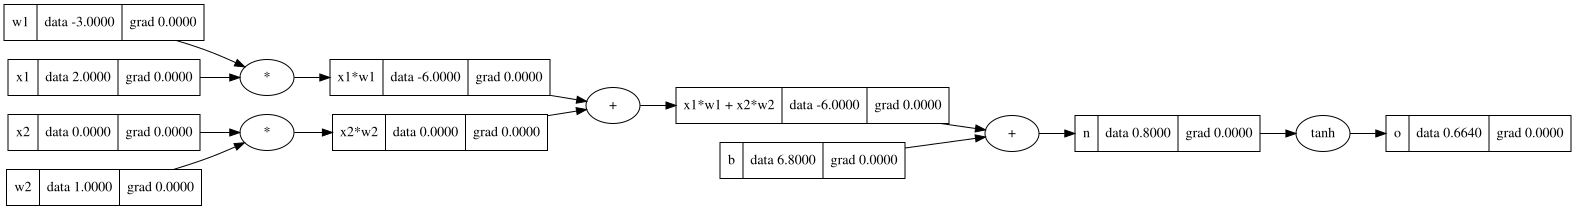

In [ ]:
draw_dot(o)

In [ ]:
o.grad = 1.0

In [ ]:
o._backward()

In [ ]:
n._backward()

In [ ]:
x1w1_x2w2._backward()

In [ ]:
x1w1._backward()
x2w2._backward()

In [ ]:
b._backward()

In [ ]:
# Above we are calling ._backward() manually we have to  make it call automatic and in the particulal order as we had called it

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad = 1.0 * out.grad
      other.grad = 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad = other.data * out.grad
      other.grad = self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad = (1 - t**2) * out.grad

    out._backward = _backward
    return out

  # Tropological graph
  def backward(self):
    topo = []
    visited = set()

    def build_topo(x):
      if x not in visited:
        visited.add(x)
        for child in x._prev:
          build_topo(child)
        topo.append(x)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

o = n.tanh(); o.label='o'

In [ ]:
o.backward()

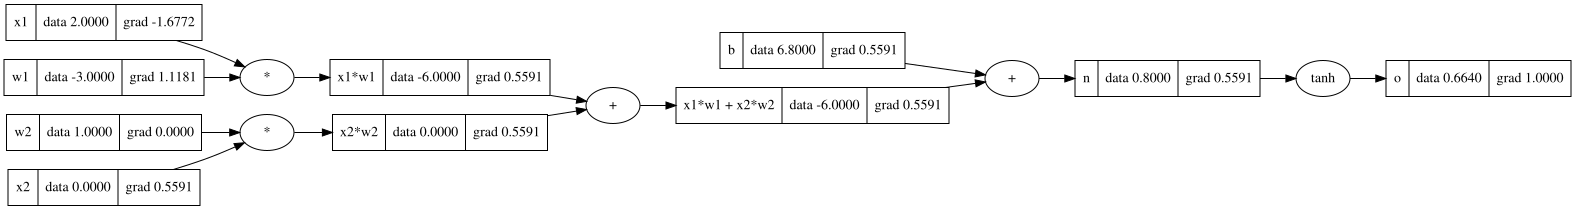

In [ ]:
draw_dot(o)

In [ ]:
# there is a bug - when same value added or multiply then grad is not calculat properly

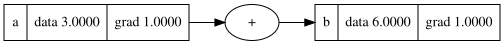

In [ ]:
# ex.
a = Value(3.0, label='a')
b = a+a; b.label='b'
b.backward()
draw_dot(b)

In [ ]:
# here a.grad should be 2.0 not 1.0

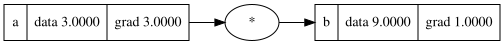

In [ ]:
# ex.
a = Value(3.0, label='a')
b = a*a; b.label='b'
b.backward()
draw_dot(b)

In [ ]:
# here a.grad should be 6.0 not 3.0

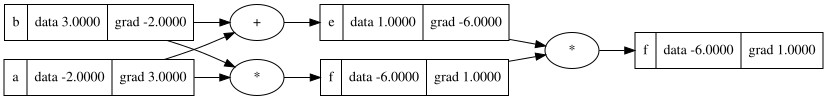

In [ ]:
# ex.
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a*b; d.label='f'
e = a+b; e.label='e'
f = d*e; f.label='f'
f.backward()
draw_dot(f)

In [ ]:
# fix = as per calculus rule we need to accumulate those gradients

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out

  # Tropological graph
  def backward(self):
    topo = []
    visited = set()

    def build_topo(x):
      if x not in visited:
        visited.add(x)
        for child in x._prev:
          build_topo(child)
        topo.append(x)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

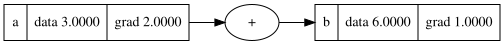

In [ ]:
a = Value(3.0, label='a')
b = a+a; b.label='b'
b.backward()
draw_dot(b)

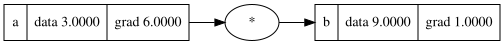

In [ ]:
a = Value(3.0, label='a')
b = a*a; b.label='b'
b.backward()
draw_dot(b)

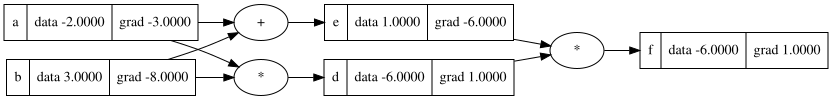

In [ ]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a*b; d.label='d'
e = a+b; e.label='e'
f = d*e; f.label='f'
f.backward()
draw_dot(f)

In [ ]:
# lets expand tanh

In [ ]:
class Value:
  def __init__(self, data, _children = (), _op = '', label = ''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self.grad = 0.0 # at start no value affect other value
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data = {self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other, label=f'{other}')     # so we can do x+1
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward
    out.label = f'({self.label}) + ({other.label})'
    return out

  def __rmul__(self, other):
    return self * other

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other, label=f'{other}')     # so we can do x*2, here we cant do 2*x, thus we will use __rmul__
    out = Value(self.data * other.data, (self, other), "*")

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    out.label = f'({self.label}) * ({other.label})'
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), "tanh")

    def _backward():
      self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    out.label = f'tanh({self.label})'
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')

    def _backward():
      self.grad += out.data * out.grad

    out._backward = _backward
    out.label = f'exp({self.label})'
    return out

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __truediv__(self, other):
    return self * other**-1

  def __pow__(self, other):
    other = other if isinstance(other, Value) else Value(other, label=f'{other}')
    assert isinstance(other.data, (int, float)), "only supporting int or float"
    out = Value(self.data**other.data, (self, other), f'**{other.label}')

    def _backward():
      self.grad += other.data * (self.data**(other.data-1)) * out.grad
      other.grad += out.data * math.log(self.data) * out.grad

    out._backward = _backward
    out.label = f'({self.label})**({other.label})'
    return out

  # Tropological graph
  def backward(self):
    topo = []
    visited = set()

    def build_topo(x):
      if x not in visited:
        visited.add(x)
        for child in x._prev:
          build_topo(child)
        topo.append(x)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [ ]:
a = Value(9.0)
2*a

Value(data = 18.0)

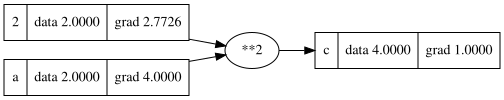

In [ ]:
a = Value(2.0); a.label='a'
b = Value(3.0); b.label='b'
c = a**2; c.label='c'

c.backward()
draw_dot(c)

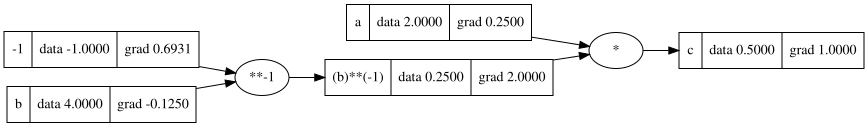

In [ ]:
a = Value(2.0); a.label='a'
b = Value(4.0); b.label='b'
c = a/b; c.label='c'

c.backward()
draw_dot(c)

In [ ]:
b - a

Value(data = 2.0)

In [ ]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of neuron
b = Value(6.8, label='b')

x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'

x1w1_x2w2 = x1w1 + x2w2; x1w1_x2w2.label='x1*w1 + x2*w2'

n = x1w1_x2w2 + b; n.label='n'

# o = n.tanh(); o.label='o'
e = (2*n).exp()
o = (e-1)/(e+1)
o.label='o'

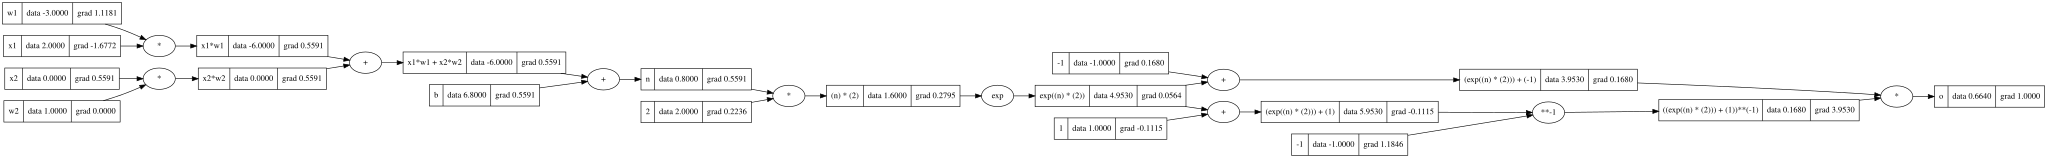

In [ ]:
o.backward()
draw_dot(o)

In [ ]:
import torch

In [ ]:
x1 = torch.Tensor([2.0]).double()   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()  ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()   ; w2.requires_grad = True
b = torch.Tensor([6.8]).double()    ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print('o', o.data.item())

o.backward()

print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())

o 0.6640368768991465
x1 -1.6771650783540835
x2 0.5590550261180278
w1 1.1181100522360556
w2 0.0


In [ ]:
o

tensor([0.6640], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [ ]:
o.data

tensor([0.6640], dtype=torch.float64)

In [ ]:
torch.Tensor([1.0]).dtype, torch.Tensor([1.0]).double().dtype

(torch.float32, torch.float64)

In [ ]:
n

tensor([0.8000], dtype=torch.float64, grad_fn=<AddBackward0>)

In [ ]:
x1

tensor([2.], dtype=torch.float64, requires_grad=True)